<H1>Introduction</H1>



1.   The data is being manually extracted from a apdf file that contains weed details (weeds of victoria) , the dataset is being extracted in two formats : json and csv .
2.   So based on the task and necessity , data cleaning process will be done





In [ ]:
import pandas as pd
import json

In [4]:
df = pd.read_csv("/content/plants.csv")

In [5]:
df.columns

Index(['page', 'common_name', 'scientific_name', 'plant_type', 'description',
       'tips', 'classification', 'icons'],
      dtype='object')

In [6]:
df.shape

(71, 8)

In [8]:
df.head()

,page,common_name,scientific_name,plant_type,description,tips,classification,icons
0,14,BLACKBERRY,Rubus fruticosus agg.,Woody,A dense forming perennial shrub with long arch...,Chemical control is best between flowering and...,Regionally Controlled Weed of National Signifi...,K|C|A|G|M|F|U|D
1,15,BONESEED AND BITOU BUSH,Chrysanthemoides monilifera,Woody,"An erect perennial evergreen shrub/small tree,...",Apply suitable herbicide whilst plant actively...,Melbourne Water Regionally Controlled North Ce...,K|L|B|C|D|M|I|F
2,16,BOXTHORN,Lycium ferocissimum,Woody,An erect thorny dense shrub growing to 5m in h...,"For chemical control, apply when tree has a he...",Regionally Controlled Weed of National Signifi...,K|C|L|P|D|U
3,17,"BRIAR ROSE (WILD ROSE, SWEET BRIAR ROSE)",Rosa rubiginosa,Woody,"An erect perennial, woody shrub up to 3m in he...",NaN,Regionally Controlled,C|D|K|M|L|N|R
4,18,CAPE BROOM & ENGLISH BROOM,Genista monspessulana and Cytisus scoparius,Woody,Slender shrubs that grow to approximately 3m i...,Broom is a prolific seeder and will quickly re...,Melbourne Water Regionally Controlled North Ce...,K|C|A|M|U|D


In [9]:
df = df.drop(columns=['page' , 'icons'])

In [10]:
df.head()


,common_name,scientific_name,plant_type,description,tips,classification
0,BLACKBERRY,Rubus fruticosus agg.,Woody,A dense forming perennial shrub with long arch...,Chemical control is best between flowering and...,Regionally Controlled Weed of National Signifi...
1,BONESEED AND BITOU BUSH,Chrysanthemoides monilifera,Woody,"An erect perennial evergreen shrub/small tree,...",Apply suitable herbicide whilst plant actively...,Melbourne Water Regionally Controlled North Ce...
2,BOXTHORN,Lycium ferocissimum,Woody,An erect thorny dense shrub growing to 5m in h...,"For chemical control, apply when tree has a he...",Regionally Controlled Weed of National Signifi...
3,"BRIAR ROSE (WILD ROSE, SWEET BRIAR ROSE)",Rosa rubiginosa,Woody,"An erect perennial, woody shrub up to 3m in he...",NaN,Regionally Controlled
4,CAPE BROOM & ENGLISH BROOM,Genista monspessulana and Cytisus scoparius,Woody,Slender shrubs that grow to approximately 3m i...,Broom is a prolific seeder and will quickly re...,Melbourne Water Regionally Controlled North Ce...


<H2>Standardising column names</H2>
Removing extra spaces and making everything to lowercase

In [11]:
df.columns = df.columns.str.strip().str.lower()

In [12]:
df.columns

Index(['common_name', 'scientific_name', 'plant_type', 'description', 'tips',
       'classification'],
      dtype='object')

In [13]:
df.isna().sum()

,0
common_name,0
scientific_name,0
plant_type,0
description,2
tips,15
classification,1


In [14]:
missing_rows = df[df.isna().any(axis=1)]
missing_rows

,common_name,scientific_name,plant_type,description,tips,classification
3,"BRIAR ROSE (WILD ROSE, SWEET BRIAR ROSE)",Rosa rubiginosa,Woody,"An erect perennial, woody shrub up to 3m in he...",NaN,Regionally Controlled
5,CHERRY LAUREL & PORTUGUESE LAUREL,Prunus laurocerasus and Prunus lusitanica,Woody,Evergreen shrubs or small tree to 5m or more c...,NaN,Environmental Weed
13,PLUM AND APPLE TREES,Prunus and Malus spp.,Woody,"Although a nice garden and orchard tree, apple...",NaN,Environmental Weed
15,SWEET PITTOSPORUM,Pittosporum undulatum,Woody,An evergreen tree or shrub with dense foliage ...,NaN,Environmental Weed Control options Method of s...
19,CAPE TULIP (ONE & TWO LEAF),Moraea flaccida & Moraea miniata,Herbs,Perennial herbs that produce salmon pink or or...,NaN,Melbourne Water Regionally Controlled North Ce...
27,RAGWORT,Senecio jacobaea,Herbs,An erect biennial or perennial herb growing to...,NaN,Melbourne Water Regionally Controlled North Ce...
28,SILVERLEAF NIGHTSHADE,Solanum elaeagnifolium,Herbs,"An erect, summer growing herb, 30 to 80cm high...",NaN,Melbourne Water Regionally Prohibited North Ce...
32,THISTLES,Herbs,Spear Thistle,NaN,NaN,Regionally Controlled Melbourne Water Regional...
34,RED HOT POKER,Kniphofia uvaria,Herb,A large tufted herb that grows to about 1.5m w...,NaN,Environmental Weed Control options Method of s...
39,"WILD GARLIC (CROW GARLIC, FIELD GARLIC)",Allium vineale,Bulbs,Erect perennial herb growing to 1m in height f...,NaN,Melbourne Water Restricted North Central Regio...


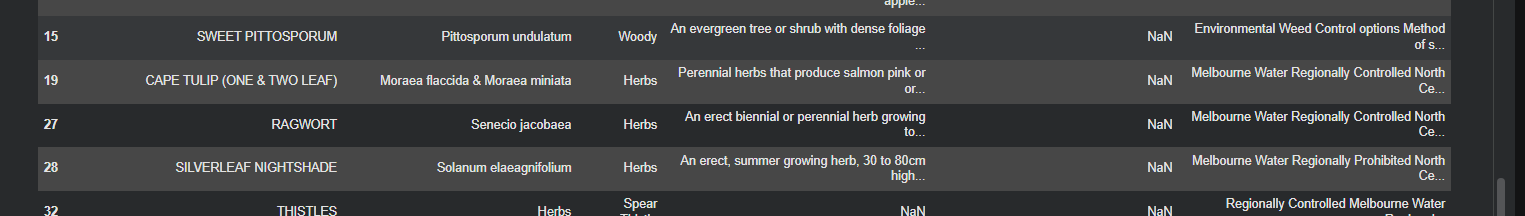

In [15]:
df[df['description'].isna()]


,common_name,scientific_name,plant_type,description,tips,classification
32,THISTLES,Herbs,Spear Thistle,NaN,NaN,Regionally Controlled Melbourne Water Regional...
49,SERRATED TUSSOCK (CONT.),Nassella trichotoma,Grasses,NaN,Manual removal is effective in small and isola...,Melbourne Water Regionally Controlled North Ce...


Fixing row 32 - Thistles

In [16]:
df.loc[32, 'scientific_name'] = None
df.loc[32, 'plant_type'] = 'Herbs'
df.loc[32, 'description'] = 'Spear Thistle'

Fixing row 49 - Serrated tussock

In [17]:
df.loc[48, 'tips'] = str(df.loc[48, 'tips']) + " " + str(df.loc[49, 'tips'])

In [18]:
df.loc[48, 'classification'] = str(df.loc[48, 'classification']) + " " + str(df.loc[49, 'classification'])

In [19]:
df = df.drop(index=49)

In [20]:
df.shape
df.loc[48]

,48
common_name,SERRATED TUSSOCK
scientific_name,Nassella trichotoma
plant_type,Grasses
description,A densely tufted perennial grass growing up to...
tips,nan Manual removal is effective in small and i...
classification,nan Melbourne Water Regionally Controlled Nort...


In [21]:
df.loc[48, 'tips'] = df.loc[48, 'tips'].replace('nan ', '').replace(' nan', '').strip()
df.loc[48, 'classification'] = df.loc[48, 'classification'].replace('nan ', '').replace(' nan', '').strip()

In [22]:
df.loc[48]

,48
common_name,SERRATED TUSSOCK
scientific_name,Nassella trichotoma
plant_type,Grasses
description,A densely tufted perennial grass growing up to...
tips,Manual removal is effective in small and isola...
classification,Melbourne Water Regionally Controlled North Ce...


In [23]:
df['plant_type'].value_counts(dropna=False)

,count
plant_type,
Woody,17
Herbs,16
Grasses,12
Trees,10
Vines/,6
Bulbs,5
Aquatic,2
Herb,1
Artichoke Thistle,1


<h2>Removing plant type inconsistancies</h2>

In [24]:
df['plant_type'] = df['plant_type'].str.replace('/', '', regex=False)

standardise singular to plural

In [25]:
df['plant_type'] = df['plant_type'].replace({
    'Herb': 'Herbs'
})

fix wrong value

In [26]:
df[df['plant_type'] == 'Artichoke Thistle']

,common_name,scientific_name,plant_type,description,tips,classification
31,THISTLES,Herbs,Artichoke Thistle,"Thistles generally favour richer soils, especi...","Saffron Thistle, Spear thistle and Variegated ...",Melbourne Water Regionally Controlled North Ce...


In [27]:
df.loc[df['plant_type'] == 'Artichoke Thistle', 'plant_type'] = 'Herbs'

In [28]:
df['plant_type'].value_counts()

,count
plant_type,
Herbs,18
Woody,17
Grasses,12
Trees,10
Vines,6
Bulbs,5
Aquatic,2


In [29]:
df['classification'].dropna().head(15)

,classification
0,Regionally Controlled Weed of National Signifi...
1,Melbourne Water Regionally Controlled North Ce...
2,Regionally Controlled Weed of National Signifi...
3,Regionally Controlled
4,Melbourne Water Regionally Controlled North Ce...
5,Environmental Weed
6,Environmental Weed Control options Method of s...
7,Melbourne Water Regionally Controlled North Ce...
8,Regionally Controlled Weed of National Signifi...
9,Melbourne Water Regionally Controlled North Ce...


remove extra phrases

In [30]:
df['classification'] = (
    df['classification']
    .str.replace('Control options', '', regex=False)
    .str.replace('Method of spread', '', regex=False)
    .str.strip()
)

In [31]:
df['classification'].dropna().head(15)

,classification
0,Regionally Controlled Weed of National Signifi...
1,Melbourne Water Regionally Controlled North Ce...
2,Regionally Controlled Weed of National Signifi...
3,Regionally Controlled
4,Melbourne Water Regionally Controlled North Ce...
5,Environmental Weed
6,Environmental Weed
7,Melbourne Water Regionally Controlled North Ce...
8,Regionally Controlled Weed of National Signifi...
9,Melbourne Water Regionally Controlled North Ce...


row 4, 7, 8, 9 has errors, we are going to put them into main categores only

In [32]:
def clean_classification(text):
    if pd.isna(text):
        return text

    if 'Environmental Weed' in text:
        return 'Environmental Weed'
    elif 'Regionally Controlled' in text:
        return 'Regionally Controlled'
    elif 'Regionally Prohibited' in text:
        return 'Regionally Prohibited'
    elif 'Restricted' in text:
        return 'Restricted'
    elif 'Weed of National Significance' in text:
        return 'Weed of National Significance'
    else:
        return text

df['classification'] = df['classification'].apply(clean_classification)

In [33]:
df['classification'].value_counts(dropna=False)

,count
classification,
Environmental Weed,38
Regionally Controlled,26
Restricted,5
Weed of National Significance,1


remove extra spaces

In [34]:
for col in ['description', 'tips']:
    df[col] = df[col].astype(str).str.strip()

fix multiple spaces

In [35]:
for col in ['description', 'tips']:
    df[col] = df[col].str.replace(r'\s+', ' ', regex=True)

Convert to sentence case

In [36]:
def to_sentence_case(text):
    if pd.isna(text):
        return text
    return text.capitalize()

for col in ['description', 'tips']:
    df[col] = df[col].apply(to_sentence_case)

checking

In [37]:
df[['description', 'tips']].head(5)

,description,tips
0,A dense forming perennial shrub with long arch...,Chemical control is best between flowering and...
1,"An erect perennial evergreen shrub/small tree,...",Apply suitable herbicide whilst plant actively...
2,An erect thorny dense shrub growing to 5m in h...,"For chemical control, apply when tree has a he..."
3,"An erect perennial, woody shrub up to 3m in he...",Nan
4,Slender shrubs that grow to approximately 3m i...,Broom is a prolific seeder and will quickly re...


In [38]:
for col in ['description', 'tips']:
    df[col] = df[col].replace(['nan', 'Nan', 'None'], pd.NA)

In [39]:
df[['description', 'tips']].head(10)

,description,tips
0,A dense forming perennial shrub with long arch...,Chemical control is best between flowering and...
1,"An erect perennial evergreen shrub/small tree,...",Apply suitable herbicide whilst plant actively...
2,An erect thorny dense shrub growing to 5m in h...,"For chemical control, apply when tree has a he..."
3,"An erect perennial, woody shrub up to 3m in he...",<NA>
4,Slender shrubs that grow to approximately 3m i...,Broom is a prolific seeder and will quickly re...
5,Evergreen shrubs or small tree to 5m or more c...,<NA>
6,An evergreen shrub or small tree to 5m or more...,For immature plants cut the stem and paint wit...
7,An evergreen perennial shrub that grows to app...,Likely to be found on roadsides and disturbed ...
8,"A dense, extremely spiny shrub up to 7m tall, ...",Gorse is a prolific seeder with seeds remainin...
9,"Tall, densely growing deciduous shrub or small...",Undertake manual control during the growing se...


check missing value again

In [40]:
df.isna().sum()

,0
common_name,0
scientific_name,1
plant_type,0
description,0
tips,14
classification,0


handle missing description

In [41]:
df = df.dropna(subset=['description'])

Final check

In [42]:
df.isna().sum()
df.shape

(70, 6)

In [43]:
df['plant_type'].value_counts()

,count
plant_type,
Herbs,18
Woody,17
Grasses,12
Trees,10
Vines,6
Bulbs,5
Aquatic,2


In [44]:
df['classification'].value_counts()

,count
classification,
Environmental Weed,38
Regionally Controlled,26
Restricted,5
Weed of National Significance,1


In [45]:
df.duplicated().sum()

np.int64(0)

In [46]:
df.sample(5, random_state=42)

,common_name,scientific_name,plant_type,description,tips,classification
22,GAZANIA,Gazania spp.,Herbs,A hairy perennial herb that grows to about 30c...,Manual removal all year round prior to seed se...,Environmental Weed
0,BLACKBERRY,Rubus fruticosus agg.,Woody,A dense forming perennial shrub with long arch...,Chemical control is best between flowering and...,Regionally Controlled
50,SPINY RUSH,Juncus acutus,Grasses,A perennial rush/tussock growing up to 1.5m hi...,<NA>,Regionally Controlled
4,CAPE BROOM & ENGLISH BROOM,Genista monspessulana and Cytisus scoparius,Woody,Slender shrubs that grow to approximately 3m i...,Broom is a prolific seeder and will quickly re...,Regionally Controlled
55,EARLY BLACK WATTLE,Acacia decurrens,Trees,"Also referred to as sydney green wattle, it is...",Seeds will germinate after rain in autumn and ...,Environmental Weed


In [47]:
df[['description', 'tips']].sample(5, random_state=1)

,description,tips
66,A dense invasive ground cover or climber with ...,Remove all stems in contact with soil. vines g...
26,"An erect, spreading, summer growing perennial ...",Flowers produced in summer on short stalks. it...
67,A trailing or climbing perennial that grows to...,Manual removal is appropriate for small infest...
55,"Also referred to as sydney green wattle, it is...",Seeds will germinate after rain in autumn and ...
27,An erect biennial or perennial herb growing to...,<NA>


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 70 entries, 0 to 70
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   common_name      70 non-null     object
 1   scientific_name  69 non-null     object
 2   plant_type       70 non-null     object
 3   description      70 non-null     object
 4   tips             56 non-null     object
 5   classification   70 non-null     object
dtypes: object(6)
memory usage: 5.9+ KB


missing value in scientific name

In [50]:
df[df['scientific_name'].isna()]

,common_name,scientific_name,plant_type,description,tips,classification
32,THISTLES,None,Herbs,Spear thistle,<NA>,Regionally Controlled


In [51]:
df.loc[32, 'scientific_name'] = 'Unknown'

post fix checking

In [53]:
df.isna().sum()

,0
common_name,0
scientific_name,0
plant_type,0
description,0
tips,14
classification,0


In [52]:
df['description'].str.len().describe()

,description
count,70.000000
mean,388.200000
std,158.796525
min,13.000000
25%,286.000000
50%,358.000000
75%,483.250000
max,960.000000


In [54]:
df.to_csv('cleaned_plants.csv', index=False)